In [424]:
import sys
from pathlib import Path

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.append(str(root / "src"))

In [425]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch
from utils import repo_root
ROOT = repo_root()

In [426]:
T = 1000
betas = torch.linspace(1e-4, 0.02, T)
betas[torch.linspace(0, T - 1, 10).long()]

tensor([1.0000e-04, 2.3111e-03, 4.5222e-03, 6.7333e-03, 8.9444e-03, 1.1156e-02,
        1.3367e-02, 1.5578e-02, 1.7789e-02, 2.0000e-02])

In [427]:
alphas = 1 - betas
alphas[torch.linspace(0, T - 1, 10).long()]

tensor([0.9999, 0.9977, 0.9955, 0.9933, 0.9911, 0.9888, 0.9866, 0.9844, 0.9822,
        0.9800])

In [428]:
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod[torch.linspace(0, T - 1, 10).long()]

tensor([9.9990e-01, 8.7360e-01, 5.9681e-01, 3.1862e-01, 1.3286e-01, 4.3250e-02,
        1.0984e-02, 2.1753e-03, 3.3573e-04, 4.0358e-05])

In [429]:
print(alphas_cumprod[0])
print(alphas_cumprod[-1])

tensor(0.9999)
tensor(4.0358e-05)


In [430]:
sqrt_alphas_cumprod = alphas_cumprod.sqrt()
sqrt_one_minus_alphas_cumprod = (1 - alphas_cumprod).sqrt()
torch.allclose(sqrt_alphas_cumprod**2 + sqrt_one_minus_alphas_cumprod**2, torch.ones(T))

True

In [431]:
dataset = datasets.MNIST(
    root=ROOT / "data",
    train=True,
    download=True,
    transform=transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ]
    ),
)

In [432]:
x0, label = dataset[0]
print(x0.min())
print(x0.max())

tensor(-1.)
tensor(1.)


In [433]:
def forward_iterative(x0, t, alphas):
    x = x0.clone()
    for i in range(t + 1):
        # move noise outside loop and result.std() = ~14, at t = 999
        noise = torch.randn_like(x0)
        x = alphas[i].sqrt() * x + (1 - alphas)[i].sqrt() * noise
    return x

In [434]:
print((forward_iterative(x0, 0, alphas) - x0).abs().max())

tensor(0.0423)


In [435]:
l = forward_iterative(x0, 999, alphas)
print(l.mean())
print(l.std())

tensor(-0.0154)
tensor(1.0378)


In [436]:
import torch
x = torch.randn(100000)
for _ in range(10):
    eps = torch.randn(100000)
    x += eps          
x.var() # x_var + 10 * eps_var = 1 + 10 * 1 = 11

tensor(11.0087)

In [437]:
x = torch.randn(100000)
eps = torch.randn(100000)
for _ in range(10):
    x += eps          
x.var()  # x_var + eps_var = 1 + 10**2 = 101

tensor(101.3282)

```-
x_t = sqrt(ᾱ_t) · x_0  +  sqrt(1 - ᾱ_t) · ε,     ε ~ N(0, I)
```

In [438]:
def q_sample(x0, t):
    noise = torch.randn_like(x0)
    return sqrt_alphas_cumprod[t] * x0 + sqrt_one_minus_alphas_cumprod[t] * noise

In [439]:
print((q_sample(x0, 0) - x0).abs().max())

tensor(0.0293)


In [440]:
l = q_sample(x0, 999)
print(l.mean())
print(l.std())

tensor(-0.0021)
tensor(1.0242)


In [441]:
loader = DataLoader(dataset, batch_size=128, shuffle=True)
images, labels = next(iter(loader))

In [442]:
x0 = images[:8]
print(x0.shape)
t = torch.randint(0, T, (8,))
print(t.shape)

torch.Size([8, 1, 28, 28])
torch.Size([8])


In [443]:
def extract(a, t, shape):
    return a[t].reshape(-1, *([1] * (len(shape) - 1)))

In [444]:
def q_sample(x0, t):
    noise = torch.randn_like(x0)
    return (
        extract(sqrt_alphas_cumprod, t, x0.shape) * x0
        + extract(sqrt_one_minus_alphas_cumprod, t, x0.shape) * noise
    )

In [445]:
q_sample(x0, t).shape

torch.Size([8, 1, 28, 28])

In [446]:
f = q_sample(x0, torch.zeros(8, dtype=torch.long))
print((f - x0).abs().max())

tensor(0.0377)


In [447]:
l = q_sample(x0, torch.full((8,), 999))
print(l.mean())
print(l.std())

tensor(0.0151)
tensor(0.9883)


5


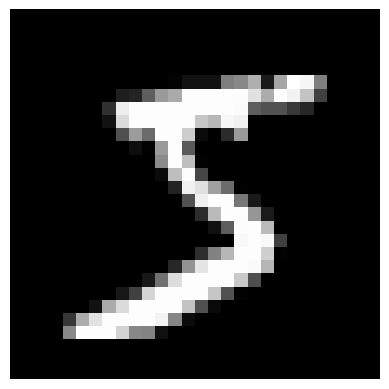

In [448]:
x0: torch.Tensor = dataset[0][0]
label = dataset[0][1]
print(label)
plt.imshow(x0[0], cmap='gray')
plt.axis('off')
plt.show()

In [449]:
x0_single = x0
x0.shape

torch.Size([1, 28, 28])

In [450]:
x0 = x0.repeat(10, 1, 1, 1)
print(x0.shape)
print(torch.equal(x0[0], x0_single))

torch.Size([10, 1, 28, 28])
True


In [451]:
t = torch.linspace(0, T - 1, 10).long()
t

tensor([  0, 111, 222, 333, 444, 555, 666, 777, 888, 999])

In [452]:
r = q_sample(x0, t)
r.shape

torch.Size([10, 1, 28, 28])

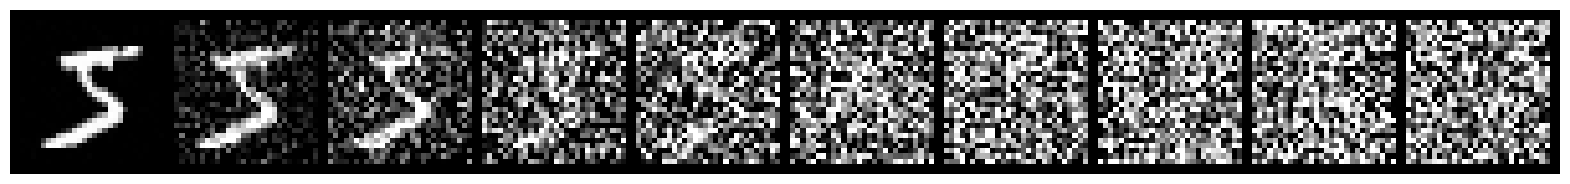

In [453]:
plt.figure(figsize=(20, 3))
plt.imshow(
    make_grid(r, nrow=10, normalize=True, value_range=(-1, 1)).permute(1, 2, 0)
)  # [H, W, C]
plt.axis('off')
plt.show()

In [454]:
import math
import torch


def timestep_embedding(t, dim):
    # t: [B] -> [B, dim]
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
    args = t[:, None].float() * freqs[None, :]  # [B, half]
    return torch.cat([args.sin(), args.cos()], dim=-1)  # [B, dim]


In [455]:
emb = timestep_embedding(torch.arange(8), 64)

assert emb.shape == (8, 64), emb.shape
assert emb.min() >= -1 and emb.max() <= 1, (emb.min(), emb.max())

near = (emb[0] - emb[1]).abs().max()
far = (emb[0] - emb[7]).abs().max()
print(f"{near=:.4f}  {far=:.4f}")
assert near < far

print("cos sim  t=0 vs t=1:", torch.cosine_similarity(emb[0], emb[1], dim=0).item())
print("cos sim  t=0 vs t=7:", torch.cosine_similarity(emb[0], emb[7], dim=0).item())


near=0.8415  far=1.9821
cos sim  t=0 vs t=1: 0.9661509990692139
cos sim  t=0 vs t=7: 0.7270102500915527


In [456]:
from torch import nn

class TinyDenoiser(nn.Module):
    def __init__(self, channels=64, time_dim=64):
        super().__init__()
        self.time_dim = time_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, channels),
        )
        self.conv_in = nn.Conv2d(1, channels, 3, padding=1)
        self.conv_mid = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv_out = nn.Conv2d(channels, 1, 3, padding=1)
        self.act = nn.SiLU()

    def forward(self, x, t):
        # x: [B, 1, 28, 28], t: [B]
        emb = self.time_mlp(timestep_embedding(t, self.time_dim))  # [B, C]
        h = self.conv_in(x)                       # [B, C, 28, 28]
        h = h + emb[:, :, None, None]             # broadcast over H, W
        h = self.act(h)
        h = self.act(self.conv_mid(h))
        return self.conv_out(h)                   # [B, 1, 28, 28]


In [457]:
torch.manual_seed(0)
model = TinyDenoiser()
x = torch.randn(8, 1, 28, 28)

out = model(x, torch.zeros(8, dtype=torch.long))
assert out.shape == x.shape, out.shape

a = model(x, torch.zeros(8, dtype=torch.long))
b = model(x, torch.full((8,), 999))
diff = (a - b).abs().max().item()
print(f"max diff t=0 vs t=999: {diff:.4f}")
assert diff > 1e-3, "time embedding is not reaching the convs"

print("params:", sum(p.numel() for p in model.parameters()))


max diff t=0 vs t=999: 0.0171
params: 46465


In [458]:
def q_sample(x0, t, noise):
    return (
        extract(sqrt_alphas_cumprod, t, x0.shape) * x0
        + extract(sqrt_one_minus_alphas_cumprod, t, x0.shape) * noise
    )

In [459]:
import torch.nn.functional as F

def loss_fn(model, x0):
    b = x0.shape[0]
    t = torch.randint(0, T, (b,))
    noise = torch.randn_like(x0)
    x_t = q_sample(x0, t, noise)          # see note below
    pred = model(x_t, t)
    return F.mse_loss(pred, noise)


In [460]:
torch.manual_seed(0)
model = TinyDenoiser()
x0 = images[:128]

losses = torch.stack([loss_fn(model, x0) for _ in range(20)])
print(f"init loss: {losses.mean():.3f} ± {losses.std():.3f}")


init loss: 0.992 ± 0.006


In [461]:
device = "cuda"

sqrt_alphas_cumprod = sqrt_alphas_cumprod.to(device)
sqrt_one_minus_alphas_cumprod = sqrt_one_minus_alphas_cumprod.to(device)

model = TinyDenoiser().to(device)
opt = torch.optim.Adam(model.parameters(), lr=2e-4)


In [462]:
import time

loader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4, drop_last=True)

for epoch in range(3):
    start, total, n = time.time(), 0.0, 0
    for images, _ in loader:
        x0 = images.to(device)
        t = torch.randint(0, T, (x0.shape[0],), device=device)
        noise = torch.randn_like(x0)

        loss = F.mse_loss(model(q_sample(x0, t, noise), t), noise)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total += loss.item()
        n += 1
    print(f"epoch {epoch}  loss {total / n:.4f}  {time.time() - start:.1f}s")


epoch 0  loss 0.1739  4.0s
epoch 1  loss 0.0695  3.7s
epoch 2  loss 0.0536  3.7s


In [463]:
betas = betas.to(device)
alphas = alphas.to(device)
sqrt_recip_alphas = (1.0 / alphas).sqrt()


range [-1.32, 1.60]  mean -0.799  std 0.532


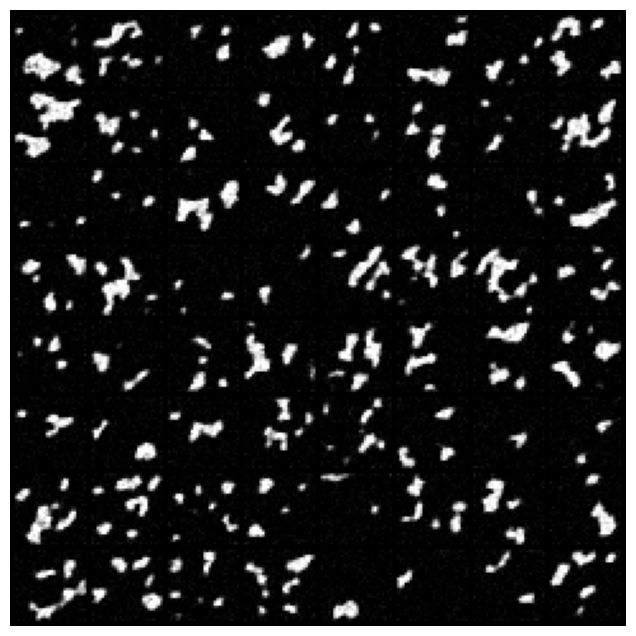

In [466]:
@torch.no_grad()
def sample(model, n=64):
    x = torch.randn(n, 1, 28, 28, device=device)
    for i in reversed(range(T)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        eps = model(x, t)
        mean = extract(sqrt_recip_alphas, t, x.shape) * (
            x - extract(betas, t, x.shape)
            / extract(sqrt_one_minus_alphas_cumprod, t, x.shape) * eps
        )
        if i == 0:
            x = mean
        else:
            x = mean + extract(betas, t, x.shape).sqrt() * torch.randn_like(x)
    return x

m = TinyDenoiser().to(device)
s = sample(model, 64)
print(f"range [{s.min():.2f}, {s.max():.2f}]  mean {s.mean():.3f}  std {s.std():.3f}")

plt.figure(figsize=(8, 8))
plt.imshow(make_grid(s.cpu(), nrow=8, normalize=True, value_range=(-1, 1)).permute(1, 2, 0))
plt.axis("off")
plt.show()
